In [1]:
 # Decision Tree Regression

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Importing the dataset
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

In [ ]:
# Splitting the dataset into the Training set and Test set
"""from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)"""

# Feature Scaling
"""from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)
sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train.reshape(-1,1))"""

In [3]:
# Fitting Decision Tree Regression to the dataset
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(X, y)

DecisionTreeRegressor()

In [4]:
# Predicting a new result
y_pred = regressor.predict([[6.5]])

In [5]:
y_pred

array([150000.])

/tmp/ipython-input-4024256648.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


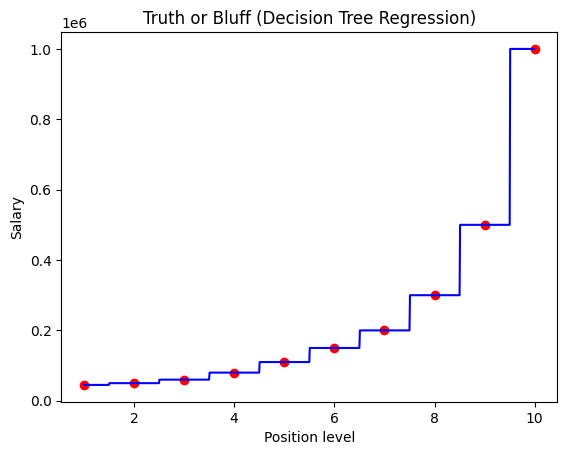

In [6]:
# Visualising the Decision Tree Regression results (higher resolution)
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, regressor.predict(X_grid), color = 'blue')
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

## More Varaibels Are better

In [7]:
import pandas as pd

# Load the CSV file
dataset = pd.read_csv('Position_Salaries.csv')

# Add the "Years of Experience" column next to "Level"
dataset.insert(2, "Years of Experience", dataset["Level"] * 1.5)  # Logical assumption

# Save the updated dataset with the correct column order
dataset.to_csv('Updated_Position_Salaries.csv', index=False)

# Confirm completion
print("✅ CSV file updated successfully. Check 'Updated_Position_Salaries.csv'.")


✅ CSV file updated successfully. Check 'Updated_Position_Salaries.csv'.


In [8]:
dataset

,Position,Level,Years of Experience,Salary
0,Business Analyst,1,1.5,45000
1,Junior Consultant,2,3.0,50000
2,Senior Consultant,3,4.5,60000
3,Manager,4,6.0,80000
4,Country Manager,5,7.5,110000
5,Region Manager,6,9.0,150000
6,Partner,7,10.5,200000
7,Senior Partner,8,12.0,300000
8,C-level,9,13.5,500000
9,CEO,10,15.0,1000000


In [10]:
X = dataset.iloc[:, [1,2]].values
y = dataset.iloc[:, 3].values

In [11]:
X

array([[ 1. ,  1.5],
       [ 2. ,  3. ],
       [ 3. ,  4.5],
       [ 4. ,  6. ],
       [ 5. ,  7.5],
       [ 6. ,  9. ],
       [ 7. , 10.5],
       [ 8. , 12. ],
       [ 9. , 13.5],
       [10. , 15. ]])

In [12]:
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

In [13]:
# Fitting Decision Tree Regression to the dataset
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(X, y)

DecisionTreeRegressor(random_state=0)

In [14]:
# Predicting a new result
y_pred = regressor.predict([[6.5 , 9.75]])

In [15]:
y_pred

array([150000.])

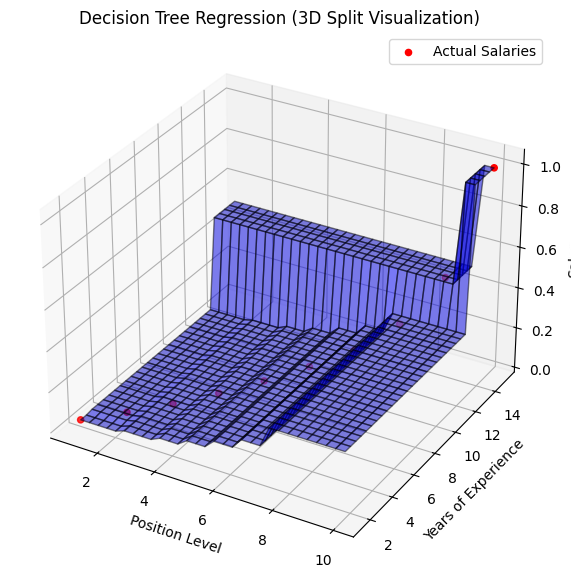

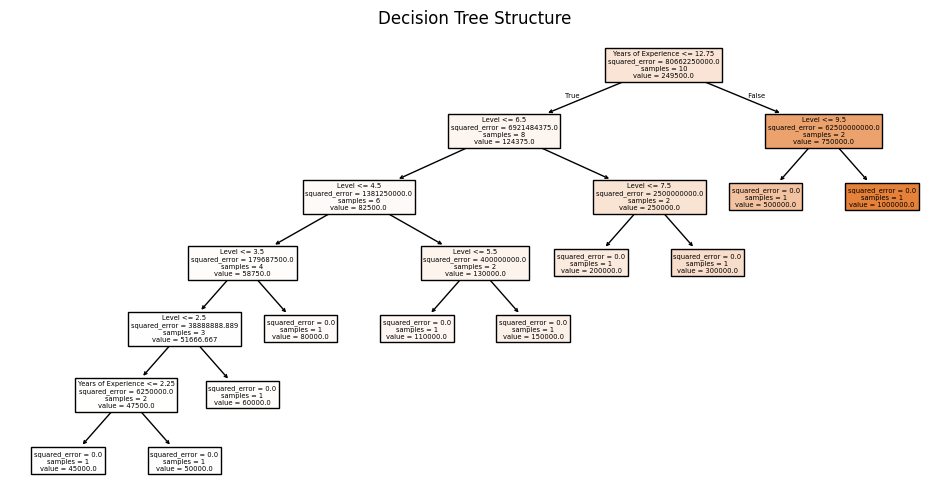

Feature Importance:
 Level: 0.2236, Years of Experience: 0.7764


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from mpl_toolkits.mplot3d import Axes3D

# 🔹 3D Visualization of Decision Tree Predictions
X_grid1, X_grid2 = np.meshgrid(
    np.linspace(min(X[:, 0]), max(X[:, 0]), 30),
    np.linspace(min(X[:, 1]), max(X[:, 1]), 30)
)
X_grid = np.c_[X_grid1.ravel(), X_grid2.ravel()]

# Predict salaries across the grid
y_grid = regressor.predict(X_grid).reshape(X_grid1.shape)

# 3D Plot of the Decision Tree Model
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter actual data points
ax.scatter(X[:, 0], X[:, 1], y, color='red', label="Actual Salaries")

# Plot Decision Tree predictions as a surface
ax.plot_surface(X_grid1, X_grid2, y_grid, color='blue', alpha=0.5, edgecolor='k')

# Labels
ax.set_xlabel("Position Level")
ax.set_ylabel("Years of Experience")
ax.set_zlabel("Salary")
ax.set_title("Decision Tree Regression (3D Split Visualization)")
plt.legend()
plt.show()

# 🔹 Show the actual Decision Tree structure
plt.figure(figsize=(12, 6))
plot_tree(regressor, feature_names=['Level', 'Years of Experience'], filled=True)
plt.title("Decision Tree Structure")
plt.show()

# 🔹 Feature Importance Analysis
feature_importance = regressor.feature_importances_
print(f"Feature Importance:\n Level: {feature_importance[0]:.4f}, Years of Experience: {feature_importance[1]:.4f}")
